In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
df = pd.read_csv("/content/titanic.csv")

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df = df.drop("Name", axis =1)

In [ ]:
df = df.drop("Ticket", axis =1)
df = df.drop("Cabin", axis =1)
df = df.drop("Embarked", axis =1)
df = df.drop("PassengerId", axis =1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


In [ ]:
df = df.fillna(0)

In [ ]:
y = df["Survived"]
df = df.drop("Survived", axis =1)
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [ ]:
X = df
map_sex = {'male': 0, 'female': 1}
df['Sex'] = df['Sex'].map(map_sex)
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,0,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,3,1,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,3,0,35.0,0,0,8.0500


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 42)

In [ ]:
X_train.shape

(623, 6)

In [ ]:
y_train.shape

(623,)

In [ ]:
y_test.shape

(268,)

In [ ]:
X_test.shape

(268, 6)

In [ ]:
nb = GaussianNB()
nb.fit(X_train,y_train)

GaussianNB()

In [ ]:
y_pred = nb.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

sample = X_test.iloc[0:1]
prediction = nb.predict(sample)

sample_dict = sample.iloc[0].to_dict()
print(f"\nSample Passenger: {sample_dict}")
print(f"Predicted Survival: {'Survived' if prediction[0] == 1 else 'Did Not Survive'}")

Accuracy: 0.79

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.83       157
           1       0.76      0.73      0.75       111

    accuracy                           0.79       268
   macro avg       0.79      0.79      0.79       268
weighted avg       0.79      0.79      0.79       268


Sample Passenger: {'Pclass': 3.0, 'Sex': 0.0, 'Age': 0.0, 'SibSp': 1.0, 'Parch': 1.0, 'Fare': 15.2458}
Predicted Survival: Did Not Survive


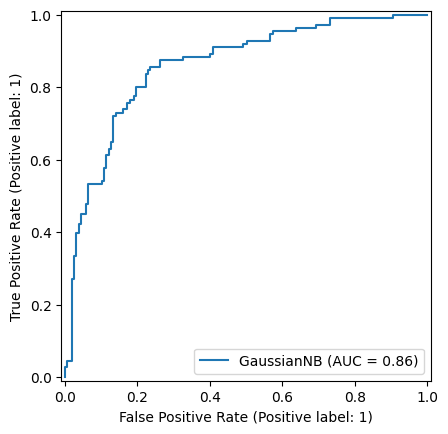

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# This plots the curve and calculates AUC automatically
RocCurveDisplay.from_estimator(nb, X_test, y_test)
plt.show()


SVM Classifier

In [ ]:
from sklearn.svm import SVC


In [ ]:
SVM = SVC()
SVM.fit(X_train, y_train)
y_pred = SVM.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

sample = X_test.iloc[0:1]
prediction = SVM.predict(sample)

sample_dict = sample.iloc[0].to_dict()
print(f"\nSample Passenger: {sample_dict}")
print(f"Predicted Survival: {'Survived' if prediction[0] == 1 else 'Did Not Survive'}")

Accuracy: 0.66

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.94      0.76       157
           1       0.74      0.26      0.39       111

    accuracy                           0.66       268
   macro avg       0.69      0.60      0.57       268
weighted avg       0.68      0.66      0.61       268


Sample Passenger: {'Pclass': 3.0, 'Sex': 0.0, 'Age': 0.0, 'SibSp': 1.0, 'Parch': 1.0, 'Fare': 15.2458}
Predicted Survival: Did Not Survive


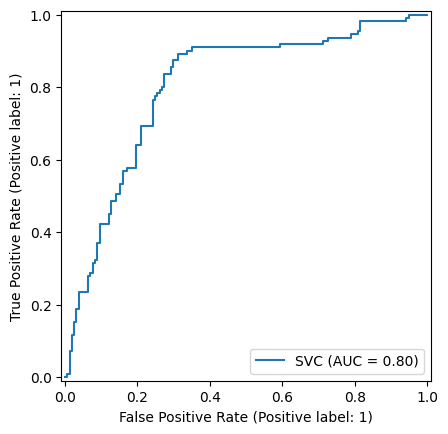

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# This plots the curve and calculates AUC automatically
RocCurveDisplay.from_estimator(SVM, X_test, y_test)
plt.show()


KNN Classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier


In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

sample = X_test.iloc[0:1]
prediction = knn.predict(sample)

sample_dict = sample.iloc[0].to_dict()
print(f"\nSample Passenger: {sample_dict}")
print(f"Predicted Survival: {'Survived' if prediction[0] == 1 else 'Did Not Survive'}")

Accuracy: 0.68

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.82      0.75       157
           1       0.65      0.50      0.56       111

    accuracy                           0.68       268
   macro avg       0.68      0.66      0.66       268
weighted avg       0.68      0.68      0.67       268


Sample Passenger: {'Pclass': 3.0, 'Sex': 0.0, 'Age': 0.0, 'SibSp': 1.0, 'Parch': 1.0, 'Fare': 15.2458}
Predicted Survival: Did Not Survive


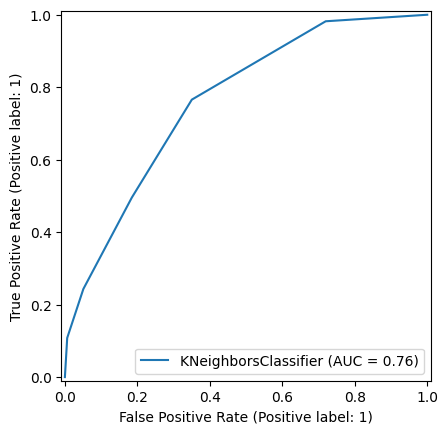

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# This plots the curve and calculates AUC automatically
RocCurveDisplay.from_estimator(knn, X_test, y_test)
plt.show()


Simple neural network [MLP]

In [1]:
# Import necessary libraries
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np



In [2]:
df = pd.read_csv("/content/banana_quality.csv")
df.head()

,Size,Weight,Sweetness,Softness,HarvestTime,Ripeness,Acidity,Quality
0,-1.924968,0.468078,3.077832,-1.472177,0.294799,2.435570,0.271290,Good
1,-2.409751,0.486870,0.346921,-2.495099,-0.892213,2.067549,0.307325,Good
2,-0.357607,1.483176,1.568452,-2.645145,-0.647267,3.090643,1.427322,Good
3,-0.868524,1.566201,1.889605,-1.273761,-1.006278,1.873001,0.477862,Good
4,0.651825,1.319199,-0.022459,-1.209709,-1.430692,1.078345,2.812442,Good


In [5]:
map_quality = {"Good":1, "Bad":0}
df["Quality"] = df["Quality"].map(map_quality)
df.head()

,Size,Weight,Sweetness,Softness,HarvestTime,Ripeness,Acidity,Quality
0,-1.924968,0.468078,3.077832,-1.472177,0.294799,2.435570,0.271290,1
1,-2.409751,0.486870,0.346921,-2.495099,-0.892213,2.067549,0.307325,1
2,-0.357607,1.483176,1.568452,-2.645145,-0.647267,3.090643,1.427322,1
3,-0.868524,1.566201,1.889605,-1.273761,-1.006278,1.873001,0.477862,1
4,0.651825,1.319199,-0.022459,-1.209709,-1.430692,1.078345,2.812442,1


In [6]:
y = df["Quality"]
X = df.drop("Quality", axis = 1)
print(X.shape, y.shape)

(8000, 7) (8000,)


In [7]:
# 1. Prepare Data
X, y = make_classification(n_samples=100, random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=1)



In [8]:
# 2. Scale features (highly recommended for MLP)
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [9]:
# 3. Import and Instantiate the model
clf = MLPClassifier()

# 4. Train the model
clf.fit(X_train_scaled, y_train)



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier()

In [10]:


# 5. Make predictions
y_pred = clf.predict(X_test_scaled)


In [11]:
print(y_pred[:5])
print(y_test[:5])

[1 0 1 1 1]
[1 0 1 1 1]


In [15]:
# 5. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)


Accuracy: 0.92

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92        13
           1       0.92      0.92      0.92        12

    accuracy                           0.92        25
   macro avg       0.92      0.92      0.92        25
weighted avg       0.92      0.92      0.92        25



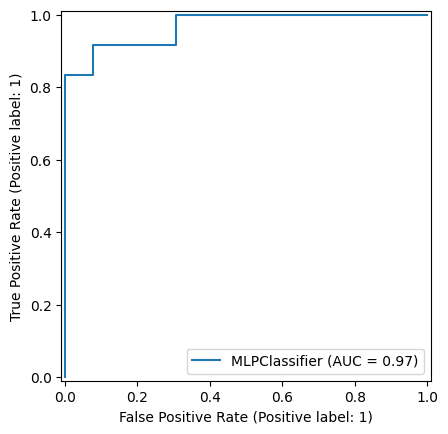

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# This plots the curve and calculates AUC automatically
RocCurveDisplay.from_estimator(clf, X_test, y_test)
plt.show()
